In [1]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import json

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
ds = pd.read_csv("../seminars/S12-hw-dataset.csv")

In [5]:
ds["date"] = pd.to_datetime(ds["date"], errors="coerce")
ds

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [6]:
ds.sort_values("date").reset_index(drop = True)

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [7]:
ds["date_date"] = ds["date"].dt.date

In [8]:
ds

,date,target,date_date
0,2025-01-01 00:00:00,98.14,2025-01-01
1,2025-01-01 01:00:00,98.07,2025-01-01
2,2025-01-01 02:00:00,104.70,2025-01-01
3,2025-01-01 03:00:00,112.81,2025-01-01
4,2025-01-01 04:00:00,112.62,2025-01-01
...,...,...,...
4315,2025-06-29 19:00:00,153.05,2025-06-29
4316,2025-06-29 20:00:00,134.23,2025-06-29
4317,2025-06-29 21:00:00,137.68,2025-06-29
4318,2025-06-29 22:00:00,126.53,2025-06-29


In [9]:
graph_ds =  ds.groupby(ds["date_date"])["target"].median().reset_index()

In [10]:
graph_ds.shape

(180, 2)

sanity-check по данным

In [11]:
print(ds.dtypes)

date         datetime64[ns]
target              float64
date_date            object
dtype: object


In [12]:
ds.shape

(4320, 3)

In [13]:
ds.describe()

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [14]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       4320 non-null   datetime64[ns]
 1   target     4320 non-null   float64       
 2   date_date  4320 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 101.4+ KB


In [15]:
ds.isna().sum()

date         0
target       0
date_date    0
dtype: int64

График ряда

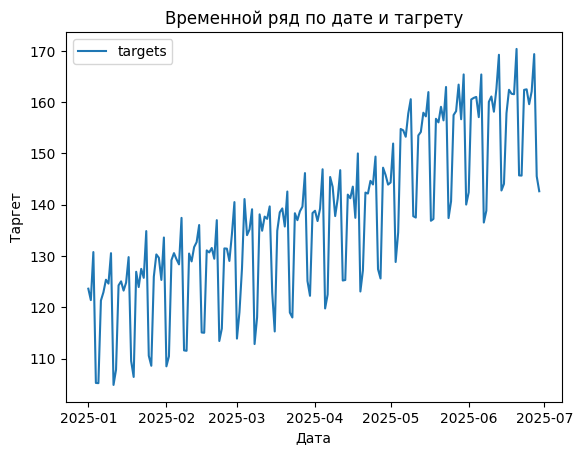

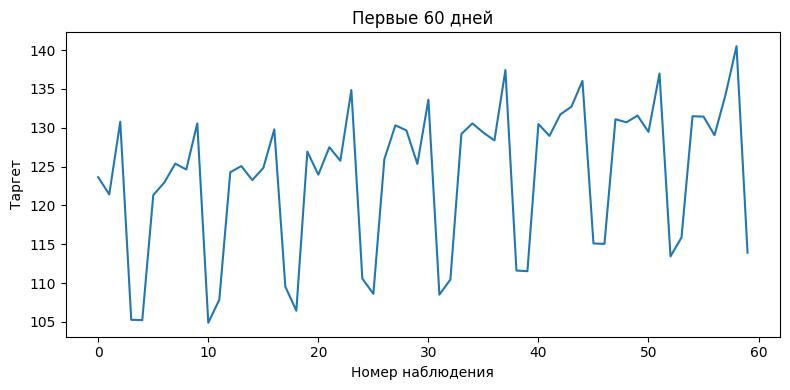

In [16]:
fig, ax = plt.subplots()
ax.plot(graph_ds["date_date"], graph_ds["target"], lw = 1.5, label = "targets")
ax.set_title("Временной ряд по дате и тагрету")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
graph_ds["target"].iloc[:60].plot(ax = axes, title = "Первые 60 дней")
axes.set_xlabel("Номер наблюдения")
axes.set_ylabel("Таргет")
plt.tight_layout()
plt.show()



Выводы о графике:

Тренд:
Выражен явно восходящий тренд, линейный рост таргета.

Сезонность:
Четко видна периодическая компонента, регулярные колебания с постоянной частотой. Видна недельная сезонность, пики и спады повторяются циклично.

Выбросы:
Выраженных выбросов не наблюдается, ряд ведет себя предсказуемо.

Нестационарность:
Ряд явно нестационарен, потому что наблюдается недельная сезонность, а также явно восходящий тренд относительно всей прямой

In [17]:
@dataclass
class SplitConfig:
    train_frac: float = 0.7
    val_frac: float = 0.15
    test_frac: float = 0.15

In [18]:
def temporal_split(df, cfg = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = df.shape[0]
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(ds)

In [19]:
print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


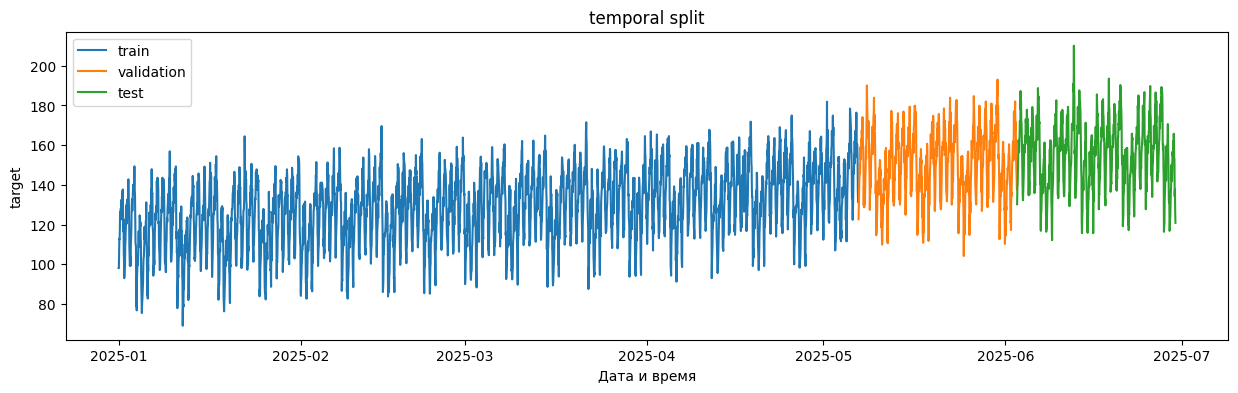

In [20]:
fig, ax = plt.subplots(figsize = (15, 4))

ax.plot(train_df["date"], train_df["target"], label = "train")
ax.plot(val_df["date"], val_df["target"], label = "validation")
ax.plot(test_df["date"], test_df["target"], label = "test")
ax.set_title("temporal split")
ax.set_xlabel("Дата и время")
ax.set_ylabel("target")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

Объяснение почему random split некорректен.

Для это задачи random split будте некорректен, потому что сама суть задачи это по данным прошлого предсказать будущее, но если мы рандомно разделяем данные, то модель будет смотреть в будущее и корректное предсказание не получится.

In [21]:
def add_calendar_features(df):
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek

    out["dow_sin"] = np.sin(2* np.pi * out["dayofweek"]/7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"]/7)

    return out

In [22]:
def add_lag_features(df, target_col = "target"):
    out = df.copy()

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window = 7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window = 7).std()
    return out

features_df = add_calendar_features(ds)
features_df = add_lag_features(features_df)

In [23]:
features_df = features_df.dropna().reset_index(drop = True)

In [24]:
feature_cols = [
    "dayofweek", 
    "dow_sin", "dow_cos",
    "lag_1", "lag_7", "lag_14", 
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

In [25]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

X_train: (3014, 8) | y_train: (3014,)
X_val:   (646, 8) | y_val:   (646,)
X_test:  (646, 8) | y_test:  (646,)


Метрики

In [26]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def evaluate_regression(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }])

B1 (naive-last): наивный baseline, где прогноз равен последнему известному значению.

In [27]:
val_pred_naive = val_feat["lag_1"].to_numpy()

baseline_results_val_b1 = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)")
], ignore_index=True)


print("Validation:")
display(baseline_results_val_b1)

Validation:


,model,MAE,RMSE,MAPE
0,Naive (lag_1),6.443406,8.203532,4.394594


In [28]:
test_pred_naive = test_feat["lag_1"].to_numpy()

baseline_results_test_b1 = pd.concat([
    evaluate_regression(y_test, test_pred_naive , "Naive (lag_1) test")
], ignore_index=True)

display(baseline_results_test_b1)

,model,MAE,RMSE,MAPE
0,Naive (lag_1) test,6.338019,8.059906,4.143508


B2 (moving-average): baseline на основе скользящего среднего по окну разумного размера

In [29]:
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val_b2 = pd.concat([evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)


print("Validation:")
display(baseline_results_val_b2 )


Validation:


,model,MAE,RMSE,MAPE
0,MovingAverage(7),12.723717,15.236326,8.828779


B3 (ridge-lag-features): Ridge (или LinearRegression) на лаговых, rolling- и календарных признаках.

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

ridge = Ridge(alpha = 1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)


val_results_b3 = pd.concat([
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results_b3)


Validation:


,model,MAE,RMSE,MAPE
0,Ridge,7.638767,9.146881,5.090831


R1 (gru-forecast): GRU на оконном представлении ряда.

In [31]:
window_size = 28 

In [32]:
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)   
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)   


In [33]:
def make_windows(series_2d, window_size):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i:i+window_size])
        y.append(series_2d[i+window_size, 0])
    return np.array(X, dtype = np.float32), np.array(y, dtype = np.float32)

In [34]:
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled , window_size)
X_test, y_test = make_windows(test_scaled, window_size)

In [35]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64

In [36]:
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)


train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False) 


xb, yb = next(iter(train_loader))
xxb, yyb = next(iter(test_loader))

In [37]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

model =  GRUForecaster(input_size=1, hidden_size=32, num_layers=1, dropout=0.0)
print(model)

GRUForecaster(
  (rnn): GRU(1, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)


In [38]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"mae": mae, "rmse": rmse}

In [39]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    all_preds, all_true = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

In [40]:
def fit_model(model, train_loader, val_loader, epochs = 12, lr = 1e-3, device = device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

        val_loss = evaluate_loss(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [41]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)


GRU  params: 37889
Epoch 01 | train_loss=0.7695 | val_loss=0.6465
Epoch 02 | train_loss=0.4325 | val_loss=0.3439
Epoch 03 | train_loss=0.2172 | val_loss=0.1883
Epoch 04 | train_loss=0.1698 | val_loss=0.1741
Epoch 05 | train_loss=0.1597 | val_loss=0.1704
Epoch 06 | train_loss=0.1556 | val_loss=0.1707
Epoch 07 | train_loss=0.1533 | val_loss=0.1720
Epoch 08 | train_loss=0.1517 | val_loss=0.1734
Epoch 09 | train_loss=0.1505 | val_loss=0.1745
Epoch 10 | train_loss=0.1494 | val_loss=0.1754
Epoch 11 | train_loss=0.1483 | val_loss=0.1759
Epoch 12 | train_loss=0.1470 | val_loss=0.1762
Epoch 13 | train_loss=0.1454 | val_loss=0.1763
Epoch 14 | train_loss=0.1435 | val_loss=0.1761
Epoch 15 | train_loss=0.1408 | val_loss=0.1758
Epoch 16 | train_loss=0.1360 | val_loss=0.1744
Epoch 17 | train_loss=0.1265 | val_loss=0.1608
Epoch 18 | train_loss=0.1147 | val_loss=0.1653
Epoch 19 | train_loss=0.1090 | val_loss=0.1697
Epoch 20 | train_loss=0.1067 | val_loss=0.1689
Epoch 21 | train_loss=0.1051 | val_loss=0

In [42]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [43]:
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

val_true = inverse_scale(gru_val_true_scaled , scaler)

gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics

,model,MAE,RMSE,MAPE
0,GRU,5.535867,7.116367,3.71253


In [44]:
torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")

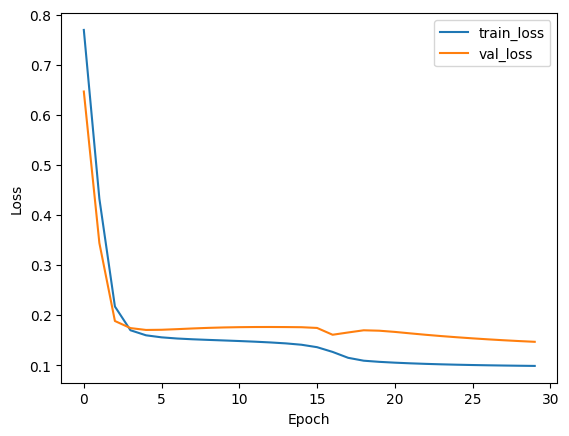

In [45]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label = "train_loss")
ax.plot(gru_history["val_loss"], label = "val_loss")
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()


По всем метрикам лучший результат показала R1.

Смотрим результаты на test.   

In [46]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics

,model,MAE,RMSE,MAPE
0,GRU,6.853155,8.632397,4.38195


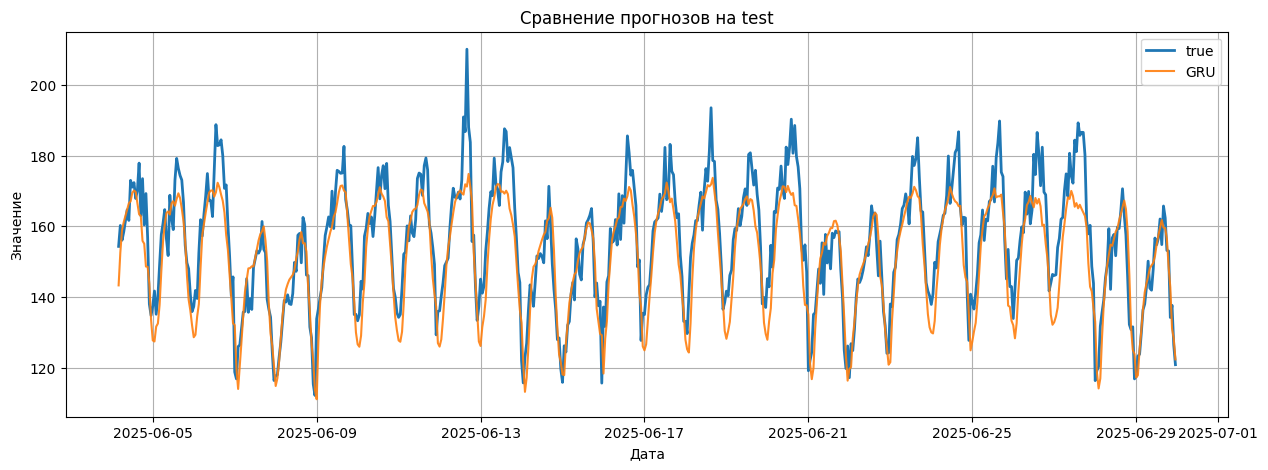

In [47]:
best_model_name = test_metrics.iloc[0]["model"]
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
ax.grid()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

In [50]:

classification_rows = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": 42,
        "split_summary": "temporal 70/15/15",
        "window_size": np.nan,
        "horizon": 1,
        "model_summary": "Naive (lag_1)",
        "features_summary": "lag_1",
        "scaler": "none",
        "optimizer": np.nan,
        "lr":np.nan,
        "epochs_trained": 0,
        "best_val_mae": baseline_results_val_b1["MAE"][0].item(),
        "best_val_rmse": baseline_results_val_b1["RMSE"][0].item(),
        "best_val_mape": baseline_results_val_b1["MAPE"][0].item(),
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "baseline_b1"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": 42,
        "split_summary": "temporal 70/15/15",
        "window_size": np.nan,
        "horizon": 1,
        "model_summary": "MovingAverage(7)",
        "features_summary": "rolling_mean_7",
        "scaler": "none",
        "optimizer": np.nan,
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_mae": baseline_results_val_b2["MAE"][0].item(),
        "best_val_rmse": baseline_results_val_b2["RMSE"][0].item(),
        "best_val_mape": baseline_results_val_b2["MAPE"][0].item(),
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "baseline_b2"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": 42,
        "split_summary": "temporal 70/15/15",
        "window_size": np.nan,
        "horizon": 1,
        "model_summary": "Ridge",
        "features_summary": "calendar + lag + rolling",
        "scaler": "StandardScaler",
        "optimizer": np.nan,
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_mae": val_results_b3["MAE"][0].item(),
        "best_val_rmse": val_results_b3["RMSE"][0].item(),
        "best_val_mape": val_results_b3["MAPE"][0].item(),
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "linear baseline"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": 42,
        "split_summary": "temporal 70/15/15",
        "window_size": int(window_size),
        "horizon": 1,
        "model_summary": "GRUForecaster(hidden=64, layers=2)",
        "features_summary": "target-only windows",
        "scaler": "StandardScaler(target)",
        "optimizer": "Adam",
        "lr": "5e-4",
        "epochs_trained": 30,
        "best_val_mae": val_metrics["MAE"][0].item(),
        "best_val_rmse": val_metrics["RMSE"][0].item(),
        "best_val_mape": val_metrics["MAPE"][0].item(),
        "test_mae": test_metrics["MAE"][0].item(),
        "test_rmse": test_metrics["RMSE"][0].item(),
        "test_mape": test_metrics["MAPE"][0].item(),
        "notes": "best by val RMSE"
    },
]

classifier_rows = pd.DataFrame(classification_rows)
display(classifier_rows)
classifier_rows.to_csv("artifacts/runs.csv", index=False)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,temporal 70/15/15,NaN,1,Naive (lag_1),lag_1,none,NaN,NaN,0,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline_b1
1,B2,forecasting,S12-hw-dataset,42,temporal 70/15/15,NaN,1,MovingAverage(7),rolling_mean_7,none,NaN,NaN,0,12.723717,15.236326,8.828779,NaN,NaN,NaN,baseline_b2
2,B3,forecasting,S12-hw-dataset,42,temporal 70/15/15,NaN,1,Ridge,calendar + lag + rolling,StandardScaler,NaN,NaN,0,7.638767,9.146881,5.090831,NaN,NaN,NaN,linear baseline
3,R1,forecasting,S12-hw-dataset,42,temporal 70/15/15,28.0,1,"GRUForecaster(hidden=64, layers=2)",target-only windows,StandardScaler(target),Adam,5e-4,30,5.535867,7.116367,3.712530,6.853155,8.632397,4.38195,best by val RMSE


In [51]:
best_gru_config = {
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "seed": 42,
    "window": 28,
    "scaler": "StandatrScaler()",
    "hidden_dims": 64,
    "num_layers": 1,
    'input_size': 1,
    "dropout_p": 0.0,
    "use_batchnorm": True,
    "learning_rate": 1e-3,
    "batch_size": 64,
    "epochs": 30,
    "test_mae": test_metrics["MAE"][0].item(),
    "test_rmse": test_metrics["RMSE"][0].item(),
    "test_mape": test_metrics["MAPE"][0].item(),
}

with open("artifacts/best_gru_config.json", "w", encoding = "utf-8") as f:
    json.dump(best_gru_config, f, indent = 4)

График сравнения эксперементов по MAE

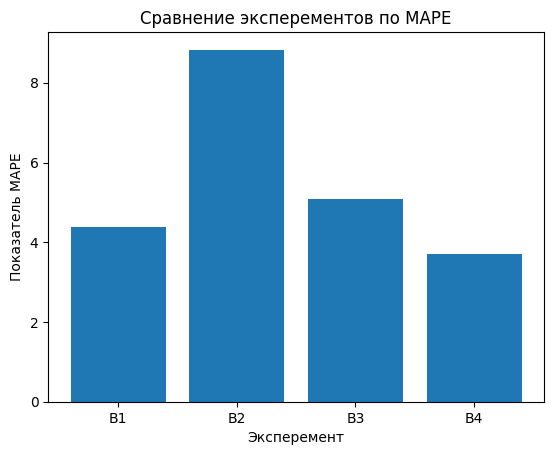

In [52]:
plt.bar(["B1", "B2", "B3", "B4"], [baseline_results_val_b1["MAPE"][0].item(), baseline_results_val_b2["MAPE"][0].item(), val_results_b3["MAPE"][0].item(), val_metrics["MAPE"][0].item()])
plt.title("Сравнение эксперементов по MAPE")
plt.xlabel("Эксперемент")
plt.ylabel("Показатель MAPE")
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()